## Analysis Notebook for Code Overflow
This notebook has the purpose of housing the actual code run to do the analysis, so we can keep the final report clean. Results are saved and used in 03-FinalProject.ipynb


## Inference Modeling

In [1]:
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt

# Load in the dataset for pipeline
df_sd_clean = pd.read_csv(
    "data/02-processed/sd_tracts_clean.csv",
    low_memory=False
)

# For saving figures + tables
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Save figures helper
def save_current_fig(filename, dpi=200):
    out = RESULTS_DIR / filename
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", out)



In [2]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = df_sd_clean.copy()
Y = "co2e_per_hh_kg"

controls = [
    "UNITS",
    "WHITE ALONE HISPANIC OR LATINO",
    "WHITE ALONE NOT HISPANIC OR LATINO",
    "BLACK OR AFRICAN AMERICAN ALONE",
    "ASIAN ALONE",
    "LESS THAN HIGH SCHOOL",
    "HIGH SCHOOL",
    "ASSOCIATES OR SOME COLLEGE",
    "BACHELORS OR HIGHER",
]
controls = [c for c in controls if c in df.columns]

df["AMI150"] = df["AMI150"].astype("category")

# Safe log: defined only for positive income
df["log_income"] = np.where(df["income_per_hh"] > 0, np.log(df["income_per_hh"]), np.nan)

FORMULAS = {
    "M0: Income only": f"{Y} ~ income_per_hh",
    "M1: Income + AMI": f"{Y} ~ income_per_hh + C(AMI150)",
    "M2: Income + AMI + Controls": f"{Y} ~ income_per_hh + C(AMI150) + " + " + ".join([f"Q('{c}')" for c in controls]),
    "M3: LogIncome + AMI + Controls": f"{Y} ~ log_income + C(AMI150) + " + " + ".join([f"Q('{c}')" for c in controls]),
}

# Consistent sample across all models
required_cols = {Y, "income_per_hh", "log_income", "AMI150"}
required_cols.update(controls)

df_model = (
    df[list(required_cols)]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print("Rows available for ALL models (consistent sample):", len(df_model))
print("Candidate models:", list(FORMULAS.keys()))

Rows available for ALL models (consistent sample): 730
Candidate models: ['M0: Income only', 'M1: Income + AMI', 'M2: Income + AMI + Controls', 'M3: LogIncome + AMI + Controls']


In [3]:
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 584
Test rows: 146


In [4]:
def cv_rmse_for_formula(df_in, formula, y_col, k=5, seed=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, va_idx in kf.split(df_in):
        tr = df_in.iloc[tr_idx]
        va = df_in.iloc[va_idx]
        m = smf.ols(formula=formula, data=tr).fit()
        pred = m.predict(va)
        rmse = np.sqrt(mean_squared_error(va[y_col], pred))
        rmses.append(rmse)
    return float(np.mean(rmses)), float(np.std(rmses))

# Select using CV on train only to avoid test leakage
cv_rows = []
for name, formula in FORMULAS.items():
    mean_rmse, std_rmse = cv_rmse_for_formula(train_df, formula, Y, k=5)
    cv_rows.append({"Model": name, "Formula": formula, "CV RMSE mean": mean_rmse, "CV RMSE std": std_rmse})

cv_df = pd.DataFrame(cv_rows).sort_values("CV RMSE mean").reset_index(drop=True)
cv_df

,Model,Formula,CV RMSE mean,CV RMSE std
0,M3: LogIncome + AMI + Controls,co2e_per_hh_kg ~ log_income + C(AMI150) + Q('U...,399.982451,65.720980
1,M2: Income + AMI + Controls,co2e_per_hh_kg ~ income_per_hh + C(AMI150) + Q...,426.667375,80.227692
2,M1: Income + AMI,co2e_per_hh_kg ~ income_per_hh + C(AMI150),465.821740,34.025501
3,M0: Income only,co2e_per_hh_kg ~ income_per_hh,466.277974,34.487861


Saved figure: results/model_comparison_cv.png


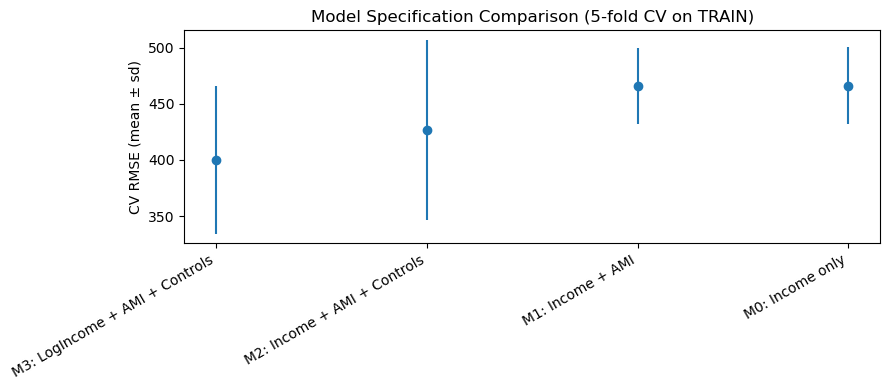

In [5]:
# Plot CV results (train-only) and save
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,4))
plt.errorbar(
    x=np.arange(len(cv_df)),
    y=cv_df["CV RMSE mean"],
    yerr=cv_df["CV RMSE std"],
    fmt="o"
)
plt.xticks(np.arange(len(cv_df)), cv_df["Model"], rotation=30, ha="right")
plt.ylabel("CV RMSE (mean ± sd)")
plt.title("Model Specification Comparison (5-fold CV on TRAIN)")
plt.tight_layout()
save_current_fig("model_comparison_cv.png")
plt.show()

In [6]:
best_model_name = cv_df.loc[0, "Model"]
best_formula = cv_df.loc[0, "Formula"]

print("Selected model (CV on TRAIN only):", best_model_name)
print("Formula:", best_formula)

# Fit selected model on TRAIN
best_train_fit = smf.ols(formula=best_formula, data=train_df).fit()

# One-time test evaluation
pred_test = best_train_fit.predict(test_df)

test_mae = mean_absolute_error(test_df[Y], pred_test)
test_rmse = np.sqrt(mean_squared_error(test_df[Y], pred_test))
test_r2 = r2_score(test_df[Y], pred_test)

final_test_metrics = pd.DataFrame([{
    "Selected_model": best_model_name,
    "Test_MAE": test_mae,
    "Test_RMSE": test_rmse,
    "Test_R2": test_r2
}])

final_test_metrics
final_test_metrics.to_csv(RESULTS_DIR / "final_selected_model_test_metrics.csv", index=False)

Selected model (CV on TRAIN only): M3: LogIncome + AMI + Controls
Formula: co2e_per_hh_kg ~ log_income + C(AMI150) + Q('UNITS') + Q('WHITE ALONE HISPANIC OR LATINO') + Q('WHITE ALONE NOT HISPANIC OR LATINO') + Q('BLACK OR AFRICAN AMERICAN ALONE') + Q('ASIAN ALONE') + Q('LESS THAN HIGH SCHOOL') + Q('HIGH SCHOOL') + Q('ASSOCIATES OR SOME COLLEGE') + Q('BACHELORS OR HIGHER')


In [7]:
# Post-selection inference (exploratory): refit on full df_model for coefficient reporting
best_full_fit_robust = smf.ols(formula=best_formula, data=df_model).fit(cov_type="HC3")
print(best_full_fit_robust.summary())

                            OLS Regression Results                            
Dep. Variable:         co2e_per_hh_kg   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     117.1
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          7.77e-181
Time:                        15:42:54   Log-Likelihood:                -5340.5
No. Observations:                 730   AIC:                         1.071e+04
Df Residuals:                     714   BIC:                         1.079e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

Saved figure: results/best_model_coefficients.png


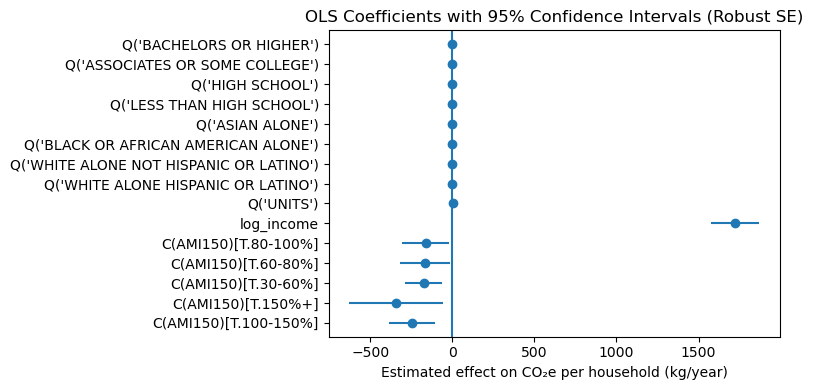

In [8]:
import matplotlib.pyplot as plt

params = best_full_fit_robust.params
conf = best_full_fit_robust.conf_int()

# Drop intercept for plotting
params = params.drop("Intercept")
conf = conf.drop("Intercept")

plt.figure(figsize=(8, max(4, len(params) * 0.25)))
plt.errorbar(
    params.values,
    params.index,
    xerr=[params.values - conf[0].values, conf[1].values - params.values],
    fmt="o"
)
plt.axvline(0)
plt.title("OLS Coefficients with 95% Confidence Intervals (Robust SE)")
plt.xlabel("Estimated effect on CO₂e per household (kg/year)")
plt.tight_layout()
save_current_fig("best_model_coefficients.png")
plt.show()

Saved figure: results/learning_curve.png


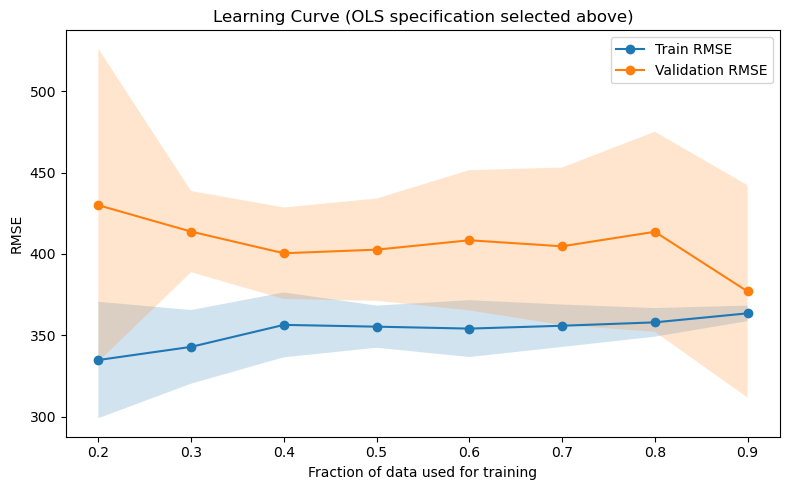

In [9]:
from sklearn.model_selection import ShuffleSplit

def learning_curve_ols(df_in, formula, y_col, train_fracs, cv=20, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df_in)
    train_rmse = []
    val_rmse = []
    
    for frac in train_fracs:
        tr_size = int(frac * n)
        tr_scores = []
        va_scores = []
        
        for _ in range(cv):
            idx = rng.permutation(n)
            tr_idx = idx[:tr_size]
            va_idx = idx[tr_size:]
            tr = df_in.iloc[tr_idx]
            va = df_in.iloc[va_idx]
            
            m = smf.ols(formula=formula, data=tr).fit()
            pred_tr = m.predict(tr)
            pred_va = m.predict(va)
            
            tr_scores.append(np.sqrt(mean_squared_error(tr[y_col], pred_tr)))
            va_scores.append(np.sqrt(mean_squared_error(va[y_col], pred_va)))
        
        train_rmse.append((np.mean(tr_scores), np.std(tr_scores)))
        val_rmse.append((np.mean(va_scores), np.std(va_scores)))
    
    return train_rmse, val_rmse

train_fracs = np.linspace(0.2, 0.9, 8)
train_scores, val_scores = learning_curve_ols(train_df, best_formula, Y, train_fracs, cv=30)

train_means = [m for m, s in train_scores]
train_stds  = [s for m, s in train_scores]
val_means   = [m for m, s in val_scores]
val_stds    = [s for m, s in val_scores]

plt.figure(figsize=(8,5))
plt.plot(train_fracs, train_means, marker="o", label="Train RMSE")
plt.plot(train_fracs, val_means, marker="o", label="Validation RMSE")
plt.fill_between(train_fracs, np.array(train_means)-np.array(train_stds), np.array(train_means)+np.array(train_stds), alpha=0.2)
plt.fill_between(train_fracs, np.array(val_means)-np.array(val_stds), np.array(val_means)+np.array(val_stds), alpha=0.2)
plt.xlabel("Fraction of data used for training")
plt.ylabel("RMSE")
plt.title("Learning Curve (OLS specification selected above)")
plt.legend()
plt.tight_layout()
save_current_fig("learning_curve.png")
plt.show()

In [10]:
# Save CV table (train-only)
cv_df.to_csv(RESULTS_DIR / "model_comparison_cv.csv", index=False)
cv_df.head()

,Model,Formula,CV RMSE mean,CV RMSE std
0,M3: LogIncome + AMI + Controls,co2e_per_hh_kg ~ log_income + C(AMI150) + Q('U...,399.982451,65.720980
1,M2: Income + AMI + Controls,co2e_per_hh_kg ~ income_per_hh + C(AMI150) + Q...,426.667375,80.227692
2,M1: Income + AMI,co2e_per_hh_kg ~ income_per_hh + C(AMI150),465.821740,34.025501
3,M0: Income only,co2e_per_hh_kg ~ income_per_hh,466.277974,34.487861
